<a href="https://colab.research.google.com/github/Liuchenxi1/StockPricePredictionByTensorflow/blob/main/Generic_Stock_TensorFlow_Forecast_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generic Stock Price Forecast — TensorFlow Showcase

Choose a U.S.-listed stock ticker once, then this notebook downloads market data, looks up its SEC CIK automatically, builds features, and compares Linear Regression, Ridge, and TensorFlow forecasts.

In [20]:
!pip install -q yfinance pandas numpy matplotlib requests scikit-learn tensorflow

## 1. Imports and project settings

In [21]:
TICKER = input("Enter the stock ticker to analyze (example: AAPL, MSFT, HCA): ").strip().upper()
BENCHMARK_TICKER = "SPY"   # Change this if you prefer a sector-specific benchmark

print("Selected ticker:", TICKER)
print("Benchmark:", BENCHMARK_TICKER)

Enter the stock ticker to analyze (example: AAPL, MSFT, HCA): HCA
Selected ticker: HCA
Benchmark: SPY


In [22]:
TICKER

'HCA'

In [23]:
import random
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf

pd.set_option("display.max_columns", 100)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

MARKET_TICKERS = list(dict.fromkeys([
    TICKER,
    BENCHMARK_TICKER,
    "^VIX",
    "^IRX",
    "^TNX",
]))

END_DATE = pd.Timestamp.today().normalize()
START_DATE = END_DATE - pd.DateOffset(years=10)

print("Start:", START_DATE.date())
print("End:  ", END_DATE.date())

Start: 2016-08-21
End:   2026-08-21


## 2. Download market data

`yfinance` returns a two-level column index when several tickers are downloaded.  
We intentionally **keep** that MultiIndex so `(field, ticker)` remains unambiguous.

In [24]:
market = yf.download(
    MARKET_TICKERS,
    start=START_DATE.strftime("%Y-%m-%d"),
    end=(END_DATE + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
    interval="1d",
    auto_adjust=False,
    progress=False,
    group_by="column",
)

if isinstance(market.columns, pd.MultiIndex):
    market.columns.names = ["Price", "Ticker"]

market = market.sort_index()

print("Rows:", len(market))
print("Column levels:", market.columns.names)

if isinstance(market.columns, pd.MultiIndex):
    print("Tickers:", market.columns.get_level_values("Ticker").unique().tolist())

market.tail()

Rows: 2515
Column levels: ['Price', 'Ticker']
Tickers: ['HCA', 'SPY', '^IRX', '^TNX', '^VIX']


Price        Adj Close                                        Close  \
Ticker             HCA         SPY   ^IRX   ^TNX   ^VIX         HCA   
Date                                                                  
2026-08-17  404.980011  772.669983  3.703  4.724  15.19  404.980011   
2026-08-18  411.730011  767.450012  3.705  4.706  15.84  411.730011   
2026-08-19  407.049988  769.059998  3.700  4.653  14.89  407.049988   
2026-08-20  406.269989  762.599976  3.703  4.696  16.01  406.269989   
2026-08-21  429.910004  765.775024  3.713  4.728  15.35  429.910004   

Price                                              High                     \
Ticker             SPY   ^IRX   ^TNX   ^VIX         HCA         SPY   ^IRX   
Date                                                                         
2026-08-17  772.669983  3.703  4.724  15.19  407.320007  776.780029  3.705   
2026-08-18  767.450012  3.705  4.706  15.84  417.989990  769.500000  3.713   
2026-08-19  769.059998  3.700  4.653  14.89  422.000000  772.469971  3.707   
2026-08-20  762.599976  3.703  4.696  16.01  411.140015  768.150024  3.705   
2026-08-21  765.775024  3.713  4.728  15.35  430.885010  766.409973  3.713   

Price                                Low                                   \
Ticker       ^TNX       ^VIX         HCA         SPY   ^IRX   ^TNX   ^VIX   
Date                                                                        
2026-08-17  4.728  15.470000  400.000000  772.510010  3.695  4.692  14.89   
2026-08-18  4.746  16.090000  406.149994  766.919983  3.705  4.704  15.60   
2026-08-19  4.684  15.950000  406.809998  768.099976  3.697  4.637  14.77   
2026-08-20  4.714  16.139999  403.350006  762.039978  3.697  4.674  14.91   
2026-08-21  4.738  15.880000  408.940002  764.169983  3.697  4.692  15.26   

Price             Open                                      Volume  \
Ticker             HCA         SPY   ^IRX   ^TNX   ^VIX        HCA   
Date                                                                 
2026-08-17  401.000000  776.179993  3.695  4.694  14.98  1005600.0   
2026-08-18  409.049988  768.700012  3.710  4.732  15.81  1450000.0   
2026-08-19  411.079987  770.359985  3.700  4.684  15.92  1436600.0   
2026-08-20  403.350006  765.960022  3.700  4.706  14.91  1063600.0   
2026-08-21  409.559998  766.049988  3.697  4.692  15.82   727009.0   

Price                                  
Ticker             SPY ^IRX ^TNX ^VIX  
Date                                   
2026-08-17  34356600.0  0.0  0.0    0  
2026-08-18  43920900.0  0.0  0.0    0  
2026-08-19  40306000.0  0.0  0.0    0  
2026-08-20  45479200.0  0.0  0.0    0  
2026-08-21  11652398.0  0.0  0.0    0

## 3. Build the clean modeling DataFrame

`market` remains the raw MultiIndex dataset.  
`df` is a separate, **single-level** modeling table. This avoids the earlier merge errors.

In [25]:
def get_ticker_column(data, field, ticker):
    if isinstance(data.columns, pd.MultiIndex):
        return data[field][ticker]
    return data[field]


df = pd.DataFrame(index=market.index.copy())
df.index.name = "Date"

# Selected stock
df["Stock_Open"] = get_ticker_column(market, "Open", TICKER)
df["Stock_High"] = get_ticker_column(market, "High", TICKER)
df["Stock_Low"] = get_ticker_column(market, "Low", TICKER)
df["Stock_Close"] = get_ticker_column(market, "Close", TICKER)
df["Stock_Adj_Close"] = get_ticker_column(market, "Adj Close", TICKER)
df["Stock_Volume"] = get_ticker_column(market, "Volume", TICKER)

# Benchmark / macro variables
df["Benchmark_Close"] = get_ticker_column(market, "Close", BENCHMARK_TICKER)
df["VIX"] = get_ticker_column(market, "Close", "^VIX")
df["Treasury_3M"] = get_ticker_column(market, "Close", "^IRX")
df["Treasury_10Y"] = get_ticker_column(market, "Close", "^TNX")

# Returns / changes
df["Stock_Return_1D"] = df["Stock_Adj_Close"].pct_change()
df["Benchmark_Return_1D"] = df["Benchmark_Close"].pct_change()
df["VIX_Change"] = df["VIX"].pct_change()
df["Treasury_3M_Change"] = df["Treasury_3M"].diff()
df["Treasury_10Y_Change"] = df["Treasury_10Y"].diff()
df["Yield_Curve_10Y_3M"] = df["Treasury_10Y"] - df["Treasury_3M"]

print("df column levels:", df.columns.nlevels)
print("df shape:", df.shape)
df.tail()

df column levels: 1
df shape: (2515, 16)


/tmp/ipykernel_3085/763361034.py:25: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["Stock_Return_1D"] = df["Stock_Adj_Close"].pct_change()
/tmp/ipykernel_3085/763361034.py:26: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["Benchmark_Return_1D"] = df["Benchmark_Close"].pct_change()


,Stock_Open,Stock_High,Stock_Low,Stock_Close,Stock_Adj_Close,Stock_Volume,Benchmark_Close,VIX,Treasury_3M,Treasury_10Y,Stock_Return_1D,Benchmark_Return_1D,VIX_Change,Treasury_3M_Change,Treasury_10Y_Change,Yield_Curve_10Y_3M
Date,,,,,,,,,,,,,,,,
2026-08-17,401.000000,407.320007,400.000000,404.980011,404.980011,1005600.0,772.669983,15.19,3.703,4.724,0.000741,-0.004727,0.065965,0.006,0.028,1.021
2026-08-18,409.049988,417.989990,406.149994,411.730011,411.730011,1450000.0,767.450012,15.84,3.705,4.706,0.016667,-0.006756,0.042791,0.002,-0.018,1.001
2026-08-19,411.079987,422.000000,406.809998,407.049988,407.049988,1436600.0,769.059998,14.89,3.700,4.653,-0.011367,0.002098,-0.059975,-0.005,-0.053,0.953
2026-08-20,403.350006,411.140015,403.350006,406.269989,406.269989,1063600.0,762.599976,16.01,3.703,4.696,-0.001916,-0.008400,0.075218,0.003,0.043,0.993
2026-08-21,409.559998,430.885010,408.940002,429.910004,429.910004,727009.0,765.775024,15.35,3.713,4.728,0.058188,0.004163,-0.041224,0.010,0.032,1.015


## 4. Money-flow and technical features

In [26]:
# Money flow
df["Typical_Price"] = (
    df["Stock_High"] + df["Stock_Low"] + df["Stock_Close"]
) / 3

df["Dollar_Volume"] = df["Typical_Price"] * df["Stock_Volume"]

price_range = (df["Stock_High"] - df["Stock_Low"]).replace(0, np.nan)

df["Money_Flow_Multiplier"] = (
    ((df["Stock_Close"] - df["Stock_Low"]) -
     (df["Stock_High"] - df["Stock_Close"]))
    / price_range
)

df["Money_Flow_Volume"] = df["Money_Flow_Multiplier"] * df["Stock_Volume"]
df["Directional_Dollar_Flow"] = df["Money_Flow_Multiplier"] * df["Dollar_Volume"]

for window in [5, 20, 60]:
    df[f"Flow_{window}D"] = df["Directional_Dollar_Flow"].rolling(window).sum()

for window in [20, 50, 200]:
    df[f"MA_{window}"] = df["Stock_Adj_Close"].rolling(window).mean()

# RSI
delta = df["Stock_Adj_Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
df["RSI_14"] = 100 - (100 / (1 + rs))

# MACD
ema_12 = df["Stock_Adj_Close"].ewm(span=12, adjust=False).mean()
ema_26 = df["Stock_Adj_Close"].ewm(span=26, adjust=False).mean()
df["MACD"] = ema_12 - ema_26
df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

# Volatility
df["Volatility_20D"] = df["Stock_Return_1D"].rolling(20).std()
df["Volatility_60D"] = df["Stock_Return_1D"].rolling(60).std()

df.tail()

,Stock_Open,Stock_High,Stock_Low,Stock_Close,Stock_Adj_Close,Stock_Volume,Benchmark_Close,VIX,Treasury_3M,Treasury_10Y,Stock_Return_1D,Benchmark_Return_1D,VIX_Change,Treasury_3M_Change,Treasury_10Y_Change,Yield_Curve_10Y_3M,Typical_Price,Dollar_Volume,Money_Flow_Multiplier,Money_Flow_Volume,Directional_Dollar_Flow,Flow_5D,Flow_20D,Flow_60D,MA_20,MA_50,MA_200,RSI_14,MACD,MACD_Signal,Volatility_20D,Volatility_60D
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-08-17,401.000000,407.320007,400.000000,404.980011,404.980011,1005600.0,772.669983,15.19,3.703,4.724,0.000741,-0.004727,0.065965,0.006,0.028,1.021,404.100006,4.063630e+08,0.360657,3.626771e+05,1.465578e+08,-1.098997e+08,1.276782e+09,NaN,400.935500,393.084298,NaN,40.544022,4.855487,4.673828,0.021666,0.022788
2026-08-18,409.049988,417.989990,406.149994,411.730011,411.730011,1450000.0,767.450012,15.84,3.705,4.706,0.016667,-0.006756,0.042791,0.002,-0.018,1.001,411.956665,5.973372e+08,-0.057429,-8.327242e+04,-3.430463e+07,1.560580e+08,8.797972e+08,NaN,402.867500,393.891185,NaN,52.665582,4.903458,4.719754,0.021827,0.022877
2026-08-19,411.079987,422.000000,406.809998,407.049988,407.049988,1436600.0,769.059998,14.89,3.700,4.653,-0.011367,0.002098,-0.059975,-0.005,-0.053,0.953,411.953328,5.918122e+08,-0.968402,-1.391206e+06,-5.731118e+08,-6.661333e+08,5.633129e+08,-2.103794e+08,404.626500,394.820238,NaN,59.561807,4.511827,4.678169,0.022065,0.022932
2026-08-20,403.350006,411.140015,403.350006,406.269989,406.269989,1063600.0,762.599976,16.01,3.703,4.696,-0.001916,-0.008400,0.075218,0.003,0.043,0.993,406.920003,4.328001e+08,-0.250326,-2.662469e+05,-1.083412e+08,-8.734571e+08,1.362098e+08,-4.106545e+08,406.114999,395.462635,NaN,53.480887,4.091355,4.560806,0.022035,0.022926
2026-08-21,409.559998,430.885010,408.940002,429.910004,429.910004,727009.0,765.775024,15.35,3.713,4.728,0.058188,0.004163,-0.041224,0.010,0.032,1.015,423.245005,3.077029e+08,0.911141,6.624077e+05,2.803607e+08,-2.888391e+08,9.307858e+08,1.844330e+08,408.500999,396.608970,NaN,66.073410,5.601113,4.768868,0.025071,0.024089


## 5. SEC fundamentals

For U.S. SEC registrants, the notebook automatically maps the selected ticker to its SEC CIK and then downloads Company Facts data. XBRL tags vary by company, so the notebook tries several common alternatives and gracefully skips unavailable fundamentals.

In [27]:
# IMPORTANT: SEC asks automated clients to identify themselves.
# Replace the example email with your own before publishing or making many requests.
SEC_USER_AGENT = "Stock TensorFlow research example research@example.com"
SEC_HEADERS = {"User-Agent": SEC_USER_AGENT}


def lookup_sec_company(ticker):
    url = "https://www.sec.gov/files/company_tickers.json"
    r = requests.get(url, headers=SEC_HEADERS, timeout=30)
    r.raise_for_status()
    companies = r.json()

    ticker = ticker.upper()
    for item in companies.values():
        if str(item.get("ticker", "")).upper() == ticker:
            return {
                "ticker": ticker,
                "title": item.get("title"),
                "cik": str(item.get("cik_str")).zfill(10),
            }
    return None


sec_company = lookup_sec_company(TICKER)
SEC_AVAILABLE = sec_company is not None

if SEC_AVAILABLE:
    STOCK_CIK = sec_company["cik"]
    SEC_URL = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{STOCK_CIK}.json"

    response = requests.get(SEC_URL, headers=SEC_HEADERS, timeout=30)
    response.raise_for_status()
    sec_data = response.json()

    print("SEC company:", sec_company["title"])
    print("Ticker:", TICKER)
    print("CIK:", STOCK_CIK)

    facts = sec_data.get("facts", {}).get("us-gaap", {})
    print("US-GAAP concepts:", len(facts))
else:
    print(f"No SEC CIK found for {TICKER}.")
    print("The notebook will continue with market/technical features only.")
    facts = {}

SEC company: HCA Healthcare, Inc.
Ticker: HCA
CIK: 0000860730
US-GAAP concepts: 469


In [28]:
def get_sec_fact(concept, unit="USD", forms=("10-Q", "10-K")):
    if concept not in facts:
        return pd.DataFrame()

    concept_data = facts[concept]

    if "units" not in concept_data:
        return pd.DataFrame()

    if unit not in concept_data["units"]:
        available_units = list(concept_data["units"].keys())
        if not available_units:
            return pd.DataFrame()
        unit = available_units[0]

    rows = []

    for item in concept_data["units"][unit]:
        if item.get("form") not in forms:
            continue

        rows.append({
            "start": item.get("start"),
            "end": item.get("end"),
            "filed": item.get("filed"),
            "form": item.get("form"),
            "fy": item.get("fy"),
            "fp": item.get("fp"),
            "value": item.get("val"),
        })

    result = pd.DataFrame(rows)

    if result.empty:
        return result

    for col in ["start", "end", "filed"]:
        if col in result.columns:
            result[col] = pd.to_datetime(result[col])

    return result.sort_values(["filed", "end"])


def first_available_fact(concepts):
    for concept in concepts:
        table = get_sec_fact(concept)
        if not table.empty:
            return concept, table
    return None, pd.DataFrame()


def prepare_fundamental_table(table, column_name):
    x = table.copy()

    x = x.rename(columns={"filed": "Available_Date"})
    x = x[["Available_Date", "end", column_name]].dropna()

    # On the same filing date, keep the observation with the latest period end.
    x = (
        x.sort_values(["Available_Date", "end"])
         .drop_duplicates("Available_Date", keep="last")
         [["Available_Date", column_name]]
    )

    return x


def merge_point_in_time(left, right):
    left_work = left.reset_index().sort_values("Date")
    right_work = right.sort_values("Available_Date")

    merged = pd.merge_asof(
        left_work,
        right_work,
        left_on="Date",
        right_on="Available_Date",
        direction="backward",
    )

    merged = (
        merged
        .drop(columns=["Available_Date"], errors="ignore")
        .set_index("Date")
    )

    return merged

In [29]:
# Common SEC XBRL alternatives. Not every company reports every concept.
concept_options = {
    "Total_Assets": ["Assets"],
    "Total_Liabilities": ["Liabilities"],
    "Cash": [
        "CashAndCashEquivalentsAtCarryingValue",
        "CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents",
    ],
    "Stockholders_Equity": [
        "StockholdersEquity",
        "StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest",
    ],
    "Revenue": [
        "RevenueFromContractWithCustomerExcludingAssessedTax",
        "Revenues",
        "SalesRevenueNet",
    ],
    "Net_Income": ["NetIncomeLoss", "ProfitLoss"],
    "Operating_Cash_Flow": ["NetCashProvidedByUsedInOperatingActivities"],
    "Capital_Expenditures": [
        "PaymentsToAcquirePropertyPlantAndEquipment",
        "PaymentsForAdditionsToPropertyPlantAndEquipment",
    ],
}

fundamental_tables = {}

for name, candidates in concept_options.items():
    concept, table = first_available_fact(candidates)

    if table.empty:
        print(f"{name}: NOT FOUND")
        continue

    table = table.rename(columns={"value": name})
    fundamental_tables[name] = prepare_fundamental_table(table, name)
    print(f"{name}: {concept} ({len(fundamental_tables[name])} filing observations)")

for name, table in fundamental_tables.items():
    df = merge_point_in_time(df, table)

# Create missing columns as NaN so later feature engineering can continue.
for name in concept_options:
    if name not in df.columns:
        df[name] = np.nan

print("\nAfter fundamental merge:", df.shape)

Total_Assets: Assets (61 filing observations)
Total_Liabilities: Liabilities (32 filing observations)
Cash: CashAndCashEquivalentsAtCarryingValue (61 filing observations)
Stockholders_Equity: StockholdersEquity (61 filing observations)
Revenue: Revenues (18 filing observations)
Net_Income: NetIncomeLoss (61 filing observations)
Operating_Cash_Flow: NetCashProvidedByUsedInOperatingActivities (46 filing observations)
Capital_Expenditures: PaymentsToAcquirePropertyPlantAndEquipment (61 filing observations)

After fundamental merge: (2515, 40)


## 6. Debt, free cash flow, ratios, and growth

Debt is built **before** debt ratios, so the old duplicate/out-of-order ratio cells are no longer needed.

In [30]:
# Prefer current + noncurrent debt components.
debt_component_options = {
    "Debt_Current": [
        "LongTermDebtAndFinanceLeaseObligationsCurrent",
        "LongTermDebtCurrent"
    ],
    "Debt_Noncurrent": [
        "LongTermDebtAndFinanceLeaseObligationsNoncurrent",
        "LongTermDebtNoncurrent"
    ],
}

debt_found = []

for name, candidates in debt_component_options.items():
    concept, table = first_available_fact(candidates)

    if not table.empty:
        table = table.rename(columns={"value": name})
        table = prepare_fundamental_table(table, name)
        df = merge_point_in_time(df, table)
        debt_found.append(name)
        print(f"{name}: {concept}")

if debt_found:
    df["Total_Debt"] = df[debt_found].sum(axis=1, min_count=1)
else:
    # Fallback if the company reports only a combined debt tag.
    concept, table = first_available_fact(["LongTermDebt"])

    if not table.empty:
        table = table.rename(columns={"value": "Total_Debt"})
        table = prepare_fundamental_table(table, "Total_Debt")
        df = merge_point_in_time(df, table)
        print("Total_Debt fallback:", concept)
    else:
        df["Total_Debt"] = np.nan
        print("WARNING: No debt concept found.")

# Free cash flow
df["Free_Cash_Flow"] = (
    df["Operating_Cash_Flow"] -
    df["Capital_Expenditures"].abs()
)

# Ratios, protected against zero denominators
df["Debt_to_Assets"] = (
    df["Total_Debt"] /
    df["Total_Assets"].replace(0, np.nan)
)

df["Cash_to_Debt"] = (
    df["Cash"] /
    df["Total_Debt"].replace(0, np.nan)
)

df["FCF_Margin"] = (
    df["Free_Cash_Flow"] /
    df["Revenue"].replace(0, np.nan)
)

# Growth features.
# Because fundamentals are point-in-time forward-filled into daily rows,
# these are mostly zero between filing updates and change on update dates.
for new_col, source_col in {
    "Revenue_Growth": "Revenue",
    "Net_Income_Growth": "Net_Income",
    "Asset_Growth": "Total_Assets",
    "Liability_Growth": "Total_Liabilities",
    "FCF_Growth": "Free_Cash_Flow",
}.items():
    df[new_col] = df[source_col].pct_change(fill_method=None)

df = df.replace([np.inf, -np.inf], np.nan).sort_index()

print(df.shape)
df.tail()

Debt_Current: LongTermDebtCurrent
Debt_Noncurrent: LongTermDebtNoncurrent
(2515, 52)


,Stock_Open,Stock_High,Stock_Low,Stock_Close,Stock_Adj_Close,Stock_Volume,Benchmark_Close,VIX,Treasury_3M,Treasury_10Y,Stock_Return_1D,Benchmark_Return_1D,VIX_Change,Treasury_3M_Change,Treasury_10Y_Change,Yield_Curve_10Y_3M,Typical_Price,Dollar_Volume,Money_Flow_Multiplier,Money_Flow_Volume,Directional_Dollar_Flow,Flow_5D,Flow_20D,Flow_60D,MA_20,MA_50,MA_200,RSI_14,MACD,MACD_Signal,Volatility_20D,Volatility_60D,Total_Assets,Total_Liabilities,Cash,Stockholders_Equity,Revenue,Net_Income,Operating_Cash_Flow,Capital_Expenditures,Debt_Current,Debt_Noncurrent,Total_Debt,Free_Cash_Flow,Debt_to_Assets,Cash_to_Debt,FCF_Margin,Revenue_Growth,Net_Income_Growth,Asset_Growth,Liability_Growth,FCF_Growth
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-08-17,401.000000,407.320007,400.000000,404.980011,404.980011,1005600.0,772.669983,15.19,3.703,4.724,0.000741,-0.004727,0.065965,0.006,0.028,1.021,404.100006,4.063630e+08,0.360657,3.626771e+05,1.465578e+08,-1.098997e+08,1.276782e+09,NaN,400.935500,393.084298,NaN,40.544022,4.855487,4.673828,0.021666,0.022788,61450000000,45623000000,940000000,-6303000000,1.910900e+10,1620000000,2014000000,1119000000,3519000000,39491000000,43010000000,895000000,0.699919,0.021855,0.046837,0.0,0.0,0.0,0.0,0.0
2026-08-18,409.049988,417.989990,406.149994,411.730011,411.730011,1450000.0,767.450012,15.84,3.705,4.706,0.016667,-0.006756,0.042791,0.002,-0.018,1.001,411.956665,5.973372e+08,-0.057429,-8.327242e+04,-3.430463e+07,1.560580e+08,8.797972e+08,NaN,402.867500,393.891185,NaN,52.665582,4.903458,4.719754,0.021827,0.022877,61450000000,45623000000,940000000,-6303000000,1.910900e+10,1620000000,2014000000,1119000000,3519000000,39491000000,43010000000,895000000,0.699919,0.021855,0.046837,0.0,0.0,0.0,0.0,0.0
2026-08-19,411.079987,422.000000,406.809998,407.049988,407.049988,1436600.0,769.059998,14.89,3.700,4.653,-0.011367,0.002098,-0.059975,-0.005,-0.053,0.953,411.953328,5.918122e+08,-0.968402,-1.391206e+06,-5.731118e+08,-6.661333e+08,5.633129e+08,-2.103794e+08,404.626500,394.820238,NaN,59.561807,4.511827,4.678169,0.022065,0.022932,61450000000,45623000000,940000000,-6303000000,1.910900e+10,1620000000,2014000000,1119000000,3519000000,39491000000,43010000000,895000000,0.699919,0.021855,0.046837,0.0,0.0,0.0,0.0,0.0
2026-08-20,403.350006,411.140015,403.350006,406.269989,406.269989,1063600.0,762.599976,16.01,3.703,4.696,-0.001916,-0.008400,0.075218,0.003,0.043,0.993,406.920003,4.328001e+08,-0.250326,-2.662469e+05,-1.083412e+08,-8.734571e+08,1.362098e+08,-4.106545e+08,406.114999,395.462635,NaN,53.480887,4.091355,4.560806,0.022035,0.022926,61450000000,45623000000,940000000,-6303000000,1.910900e+10,1620000000,2014000000,1119000000,3519000000,39491000000,43010000000,895000000,0.699919,0.021855,0.046837,0.0,0.0,0.0,0.0,0.0
2026-08-21,409.559998,430.885010,408.940002,429.910004,429.910004,727009.0,765.775024,15.35,3.713,4.728,0.058188,0.004163,-0.041224,0.010,0.032,1.015,423.245005,3.077029e+08,0.911141,6.624077e+05,2.803607e+08,-2.888391e+08,9.307858e+08,1.844330e+08,408.500999,396.608970,NaN,66.073410,5.601113,4.768868,0.025071,0.024089,61450000000,45623000000,940000000,-6303000000,1.910900e+10,1620000000,2014000000,1119000000,3519000000,39491000000,43010000000,895000000,0.699919,0.021855,0.046837,0.0,0.0,0.0,0.0,0.0


## 7. Features and forecast horizons

The latest complete feature row is used for the real forecast. The notebook automatically creates targets for the end of the current calendar year and the end of the following year.

In [31]:
FEATURES = [
    # Selected stock
    "Stock_Adj_Close",
    "Stock_Volume",
    "Stock_Return_1D",

    # Trading / money flow
    "Dollar_Volume",
    "Money_Flow_Multiplier",
    "Money_Flow_Volume",
    "Directional_Dollar_Flow",
    "Flow_5D",
    "Flow_20D",
    "Flow_60D",

    # Technical
    "MA_20",
    "MA_50",
    "MA_200",
    "RSI_14",
    "MACD",
    "MACD_Signal",
    "Volatility_20D",
    "Volatility_60D",

    # Benchmark / market
    "Benchmark_Close",
    "Benchmark_Return_1D",
    "VIX",
    "VIX_Change",

    # Rates
    "Treasury_3M",
    "Treasury_10Y",
    "Treasury_3M_Change",
    "Treasury_10Y_Change",
    "Yield_Curve_10Y_3M",

    # Fundamentals
    "Total_Assets",
    "Total_Liabilities",
    "Cash",
    "Total_Debt",
    "Stockholders_Equity",
    "Revenue",
    "Net_Income",
    "Operating_Cash_Flow",
    "Capital_Expenditures",
    "Free_Cash_Flow",

    # Ratios
    "Debt_to_Assets",
    "Cash_to_Debt",
    "FCF_Margin",

    # Growth
    "Revenue_Growth",
    "Net_Income_Growth",
    "Asset_Growth",
    "Liability_Growth",
    "FCF_Growth",
]

# --------------------------------------------------
# Generic feature availability
# --------------------------------------------------

existing_features = [x for x in FEATURES if x in df.columns]
missing_features = [x for x in FEATURES if x not in df.columns]

# Remove only columns that never contain a value.
all_nan_features = [
    x for x in existing_features
    if df[x].notna().sum() == 0
]

candidate_features = [
    x for x in existing_features
    if x not in all_nan_features
]

# Carry the most recently known value forward.
# This is especially important for quarterly SEC data.
feature_frame = (
    df[candidate_features]
    .replace([np.inf, -np.inf], np.nan)
    .ffill()
)

# The forecast should start from the newest stock-price observation,
# not from the newest row where every feature happens to be complete.
latest_date = df["Stock_Adj_Close"].last_valid_index()

if latest_date is None:
    raise ValueError(f"No usable price history was downloaded for {TICKER}.")

latest_stock_price = float(
    df.loc[latest_date, "Stock_Adj_Close"]
)

latest_row = feature_frame.loc[[latest_date]].copy()

# A feature cannot be used for the final forecast if no value is known
# by the latest date.
latest_missing_features = [
    x for x in candidate_features
    if pd.isna(latest_row.iloc[0][x])
]

available_features = [
    x for x in candidate_features
    if x not in latest_missing_features
]

latest_features = latest_row[available_features].copy()

print("Requested features:", len(FEATURES))
print("Features present:", len(existing_features))
print("Features usable for latest forecast:", len(available_features))

if missing_features:
    print("\nMissing columns:")
    print(missing_features)

if all_nan_features:
    print("\nRemoved because they have no historical values:")
    print(all_nan_features)

if latest_missing_features:
    print("\nRemoved because no value is known by the latest forecast date:")
    print(latest_missing_features)

print("\nLatest market/forecast date:", latest_date.date())
print(f"Latest {TICKER} adjusted close: ${latest_stock_price:,.2f}")

# --------------------------------------------------
# Forecast horizons
# --------------------------------------------------

current_year = int(END_DATE.year)

TARGET_DATES = {
    f"End_{current_year}": pd.Timestamp(f"{current_year}-12-31"),
    f"End_{current_year + 1}": pd.Timestamp(f"{current_year + 1}-12-31"),
}

HORIZONS = {}

for name, target_date in TARGET_DATES.items():

    business_days = np.busday_count(
        latest_date.date(),
        target_date.date()
    )

    HORIZONS[name] = max(int(business_days), 1)

print("\nForecast horizons:", HORIZONS)

for name, horizon in HORIZONS.items():

    target_col = f"Target_{name}_Return"

    df[target_col] = (
        df["Stock_Adj_Close"].shift(-horizon)
        / df["Stock_Adj_Close"]
        - 1
    )

Requested features: 45
Features present: 45
Features usable for latest forecast: 45

Latest market/forecast date: 2026-08-21
Latest HCA adjusted close: $429.91

Forecast horizons: {'End_2026': 94, 'End_2027': 355}


## 8. Prepare chronological train / validation / test data

No random shuffle is used. The oldest observations train the models and the newest historical observations test them.

The same scaled data is then supplied to Linear Regression, Ridge, and TensorFlow for a fair comparison.

In [32]:
def prepare_horizon_dataset(
    name,
    train_ratio=0.70,
    val_ratio=0.15,
    min_feature_coverage=0.60,
):
    """
    Prepare one forecast horizon without requiring every historical row
    to have every SEC/fundamental feature.

    Steps:
    1. Keep rows where the future target is known.
    2. Chronologically split train / validation / test.
    3. Keep features with adequate coverage in the TRAIN period.
    4. Learn missing-value medians from TRAIN only.
    5. Standardize using TRAIN only.
    """

    target_col = f"Target_{name}_Return"

    # Attach the target, but do NOT drop rows just because one feature is NaN.
    model_data = feature_frame[available_features].copy()
    model_data[target_col] = df[target_col]

    model_data = (
        model_data
        .replace([np.inf, -np.inf], np.nan)
        .loc[lambda x: x[target_col].notna()]
        .sort_index()
        .copy()
    )

    n = len(model_data)

    if n < 100:
        raise ValueError(
            f"{name} has only {n} rows with a known future target. "
            f"Try a ticker with more price history or use a shorter forecast horizon."
        )

    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train = model_data.iloc[:train_end].copy()
    val = model_data.iloc[train_end:val_end].copy()
    test = model_data.iloc[val_end:].copy()

    # --------------------------------------------------
    # Choose features using TRAINING data only
    # --------------------------------------------------

    train_coverage = train[available_features].notna().mean()

    model_features = train_coverage[
        train_coverage >= min_feature_coverage
    ].index.tolist()

    dropped_for_coverage = [
        f for f in available_features
        if f not in model_features
    ]

    if len(model_features) < 5:
        raise ValueError(
            f"{name} has only {len(model_features)} sufficiently populated "
            "training features. Inspect SEC/history coverage."
        )

    X_train = train[model_features].copy()
    y_train = train[target_col].copy()

    X_val = val[model_features].copy()
    y_val = val[target_col].copy()

    X_test = test[model_features].copy()
    y_test = test[target_col].copy()

    # --------------------------------------------------
    # Missing-value handling WITHOUT future leakage
    # --------------------------------------------------
    # Medians are learned only from the training period.

    train_medians = X_train.median()

    # Safety: remove any feature that somehow still has no train median.
    valid_median_features = train_medians[
        train_medians.notna()
    ].index.tolist()

    if len(valid_median_features) != len(model_features):
        no_train_values = [
            f for f in model_features
            if f not in valid_median_features
        ]
        print(f"\n{name} removed features with no train values:")
        print(no_train_values)

        model_features = valid_median_features
        X_train = X_train[model_features]
        X_val = X_val[model_features]
        X_test = X_test[model_features]
        train_medians = X_train.median()

    X_train = X_train.fillna(train_medians)
    X_val = X_val.fillna(train_medians)
    X_test = X_test.fillna(train_medians)

    latest_for_model = (
        latest_features[model_features]
        .copy()
        .fillna(train_medians)
    )

    # --------------------------------------------------
    # Scaling: fit TRAIN only
    # --------------------------------------------------

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    latest_scaled = scaler.transform(latest_for_model)

    print(f"\n{name}")
    print("-" * 68)
    print("Rows with known target:", n)
    print("Features used:", len(model_features))

    if dropped_for_coverage:
        print(
            f"Features removed for < {min_feature_coverage:.0%} "
            f"training coverage: {len(dropped_for_coverage)}"
        )

    print(
        "Train:",
        X_train.index.min().date(),
        "->",
        X_train.index.max().date(),
        f"({len(X_train):,} rows)"
    )

    print(
        "Validation:",
        X_val.index.min().date(),
        "->",
        X_val.index.max().date(),
        f"({len(X_val):,} rows)"
    )

    print(
        "Test:",
        X_test.index.min().date(),
        "->",
        X_test.index.max().date(),
        f"({len(X_test):,} rows)"
    )

    return {
        "name": name,
        "target": target_col,
        "model_data": model_data,
        "features": model_features,
        "train_medians": train_medians,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "X_train_scaled": X_train_scaled,
        "X_val_scaled": X_val_scaled,
        "X_test_scaled": X_test_scaled,
        "latest_scaled": latest_scaled,
        "scaler": scaler,
    }


datasets = {
    name: prepare_horizon_dataset(name)
    for name in HORIZONS
}


End_2026
--------------------------------------------------------------------
Rows with known target: 2420
Features used: 42
Features removed for < 60% training coverage: 3
Train: 2016-08-22 -> 2023-05-15 (1,694 rows)
Validation: 2023-05-16 -> 2024-10-23 (363 rows)
Test: 2024-10-24 -> 2026-04-09 (363 rows)

End_2027
--------------------------------------------------------------------
Rows with known target: 2159
Features used: 42
Features removed for < 60% training coverage: 3
Train: 2016-08-22 -> 2022-08-22 (1,511 rows)
Validation: 2022-08-23 -> 2023-12-05 (324 rows)
Test: 2023-12-06 -> 2025-03-25 (324 rows)


## 9. Linear Regression and Ridge baselines

In [33]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


baseline_models = {}
comparison_rows = []

for name, data in datasets.items():

    # Linear Regression
    linear = LinearRegression()
    linear.fit(
        data["X_train_scaled"],
        data["y_train"]
    )

    linear_pred = linear.predict(data["X_test_scaled"])
    linear_metrics = regression_metrics(data["y_test"], linear_pred)

    baseline_models[(name, "LinearRegression")] = linear

    comparison_rows.append({
        "Horizon": name,
        "Model": "LinearRegression",
        **linear_metrics,
    })

    # Ridge
    ridge = Ridge(alpha=1.0)
    ridge.fit(
        data["X_train_scaled"],
        data["y_train"]
    )

    ridge_pred = ridge.predict(data["X_test_scaled"])
    ridge_metrics = regression_metrics(data["y_test"], ridge_pred)

    baseline_models[(name, "Ridge")] = ridge

    comparison_rows.append({
        "Horizon": name,
        "Model": "Ridge",
        **ridge_metrics,
    })

baseline_results = pd.DataFrame(comparison_rows)
baseline_results

,Horizon,Model,MAE,RMSE,R2
0,End_2026,LinearRegression,0.382737,0.461608,-5.560543
1,End_2026,Ridge,0.271276,0.329238,-2.337431
2,End_2027,LinearRegression,1.494852,1.619954,-287.408093
3,End_2027,Ridge,1.199927,1.279819,-179.011154


## 10. TensorFlow neural network

This is the main showcase model. Early stopping uses the chronological validation period.

In [34]:
def build_tensorflow_model(n_features):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"],
    )

    return model


tf_models = {}
tf_histories = {}

for name, data in datasets.items():

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_tensorflow_model(
        data["X_train_scaled"].shape[1]
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
    )

    history = model.fit(
        data["X_train_scaled"],
        data["y_train"],
        validation_data=(
            data["X_val_scaled"],
            data["y_val"],
        ),
        epochs=300,
        batch_size=32,
        verbose=0,
        callbacks=[early_stopping],
    )

    tf_models[name] = model
    tf_histories[name] = history

    print(
        name,
        "- epochs:",
        len(history.history["loss"]),
        "- best val loss:",
        min(history.history["val_loss"]),
    )

End_2026 - epochs: 43 - best val loss: 0.027622798457741737
End_2027 - epochs: 40 - best val loss: 0.1726781129837036


## 11. Compare all three models

MAE (Mean Absolute Error): This metric measures the average magnitude of the errors in a set of predictions, without considering their direction. It's the average of the absolute differences between your model's predictions and the actual values. A lower MAE indicates a better model.

RMSE (Root Mean Squared Error): This is another measure of the average magnitude of error. It's the square root of the average of the squared differences between predictions and actual values. RMSE penalizes large errors more heavily than MAE due to the squaring of errors. Like MAE, a lower RMSE indicates a better model.

R² (R-squared) or Coefficient of Determination: This metric represents the proportion of the variance in the dependent variable that can be predicted from the independent variable(s) in the model. In simpler terms, it tells you how well your model explains the variability of the target variable. R² values range from 0 to 1, where 1 means the model perfectly explains the variance, and 0 means it explains none of the variance. However, a negative R² (as seen in your output for Linear Regression and Ridge) can occur when the model performs worse than simply predicting the mean of the target variable. A higher R² (closer to 1) generally indicates a better fit.

In [35]:
comparison_rows = []

for name, data in datasets.items():

    # Linear
    linear = baseline_models[(name, "LinearRegression")]
    pred = linear.predict(data["X_test_scaled"])

    comparison_rows.append({
        "Horizon": name,
        "Model": "LinearRegression",
        **regression_metrics(data["y_test"], pred),
    })

    # Ridge
    ridge = baseline_models[(name, "Ridge")]
    pred = ridge.predict(data["X_test_scaled"])

    comparison_rows.append({
        "Horizon": name,
        "Model": "Ridge",
        **regression_metrics(data["y_test"], pred),
    })

    # TensorFlow
    model = tf_models[name]
    pred = model.predict(
        data["X_test_scaled"],
        verbose=0
    ).reshape(-1)

    comparison_rows.append({
        "Horizon": name,
        "Model": "TensorFlow NN",
        **regression_metrics(data["y_test"], pred),
    })

comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(["Horizon", "MAE"])
    .reset_index(drop=True)
)

comparison

,Horizon,Model,MAE,RMSE,R2
0,End_2026,TensorFlow NN,0.173863,0.222313,-0.521681
1,End_2026,Ridge,0.271276,0.329238,-2.337431
2,End_2026,LinearRegression,0.382737,0.461608,-5.560543
3,End_2027,TensorFlow NN,0.286804,0.364026,-13.563517
4,End_2027,Ridge,1.199927,1.279819,-179.011154
5,End_2027,LinearRegression,1.494852,1.619954,-287.408093


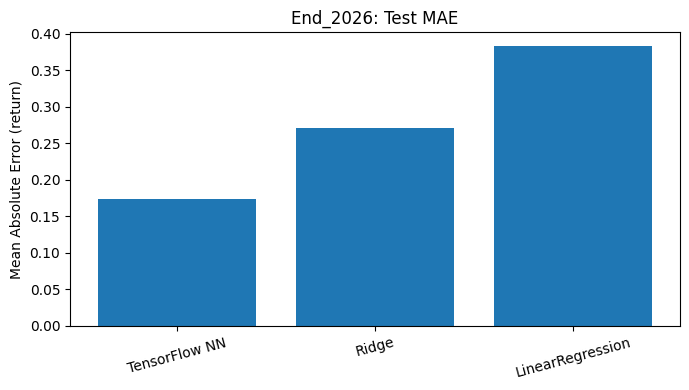

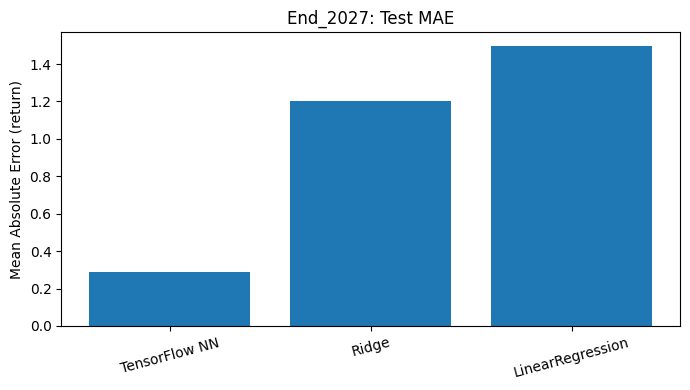

In [36]:
# Visual comparison: lower MAE is better
for horizon in comparison["Horizon"].unique():
    subset = comparison[comparison["Horizon"] == horizon]

    plt.figure(figsize=(7, 4))
    plt.bar(subset["Model"], subset["MAE"])
    plt.title(f"{horizon}: Test MAE")
    plt.ylabel("Mean Absolute Error (return)")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

## 12. Latest stock forecasts and empirical price ranges

For each model, predict the selected stock's future return from the latest usable feature row, convert that return into a price, and estimate an empirical range from historical test residuals.

In [37]:
forecast_rows = []

for name, data in datasets.items():

    target_date = TARGET_DATES[name]

    model_specs = [
        (
            "LinearRegression",
            baseline_models[(name, "LinearRegression")]
        ),
        (
            "Ridge",
            baseline_models[(name, "Ridge")]
        ),
        (
            "TensorFlow NN",
            tf_models[name]
        ),
    ]

    for model_name, model in model_specs:

        if model_name == "TensorFlow NN":
            test_pred = model.predict(
                data["X_test_scaled"],
                verbose=0
            ).reshape(-1)

            forecast_return = float(
                model.predict(
                    data["latest_scaled"],
                    verbose=0
                ).reshape(-1)[0]
            )

        else:
            test_pred = model.predict(data["X_test_scaled"])
            forecast_return = float(
                model.predict(data["latest_scaled"])[0]
            )

        residuals = data["y_test"].to_numpy() - test_pred

        residual_low = np.quantile(residuals, 0.10)
        residual_high = np.quantile(residuals, 0.90)

        return_low = forecast_return + residual_low
        return_high = forecast_return + residual_high

        central_price = latest_stock_price * (1 + forecast_return)
        low_price = max(
            0,
            latest_stock_price * (1 + return_low)
        )
        high_price = max(
            0,
            latest_stock_price * (1 + return_high)
        )

        forecast_rows.append({
            "Target_Date": target_date.date(),
            "Horizon": name,
            "Model": model_name,
            "Latest_Price": latest_stock_price,
            "Predicted_Return": forecast_return,
            "Forecast_Price": central_price,
            "Range_Low": min(low_price, high_price),
            "Range_High": max(low_price, high_price),
        })

forecast_table = pd.DataFrame(forecast_rows)

display(
    forecast_table.style.format({
        "Latest_Price": "${:,.2f}",
        "Predicted_Return": "{:.1%}",
        "Forecast_Price": "${:,.2f}",
        "Range_Low": "${:,.2f}",
        "Range_High": "${:,.2f}",
    })
)

,Target_Date,Horizon,Model,Latest_Price,Predicted_Return,Forecast_Price,Range_Low,Range_High
0,2026-12-31,End_2026,LinearRegression,$429.91,21.4%,$522.01,$433.27,$900.91
1,2026-12-31,End_2026,Ridge,$429.91,35.4%,$581.89,$499.40,$828.36
2,2026-12-31,End_2026,TensorFlow NN,$429.91,25.4%,$539.32,$370.71,$601.59
3,2027-12-31,End_2027,LinearRegression,$429.91,-33.1%,$287.41,$525.08,"$1,267.43"
4,2027-12-31,End_2027,Ridge,$429.91,-23.4%,$329.26,$553.12,"$1,078.05"
5,2027-12-31,End_2027,TensorFlow NN,$429.91,4.3%,$448.38,$434.83,$679.51


In [38]:
print(f"{TICKER} PRICE FORECAST SUMMARY")
print("=" * 72)
print(f"Latest usable date: {latest_date.date()}")
print(f"Latest {TICKER} adjusted close: ${latest_stock_price:,.2f}")

for name in TARGET_DATES:
    row = forecast_table[
        (forecast_table["Horizon"] == name) &
        (forecast_table["Model"] == "TensorFlow NN")
    ].iloc[0]

    print()
    print(f"TensorFlow — target {row['Target_Date']}")
    print(f"Predicted return: {row['Predicted_Return']:.1%}")
    print(f"Central price estimate: ${row['Forecast_Price']:,.2f}")
    print(
        "Historical residual range: "
        f"${row['Range_Low']:,.2f} - ${row['Range_High']:,.2f}"
    )

HCA PRICE FORECAST SUMMARY
Latest usable date: 2026-08-21
Latest HCA adjusted close: $429.91

TensorFlow — target 2026-12-31
Predicted return: 25.4%
Central price estimate: $539.32
Historical residual range: $370.71 - $601.59

TensorFlow — target 2027-12-31
Predicted return: 4.3%
Central price estimate: $448.38
Historical residual range: $434.83 - $679.51


## 13. Interpretation notes

- **Linear Regression** is the simple linear benchmark.
- **Ridge** tests whether regularized linear relationships generalize better.
- **TensorFlow** tests whether nonlinear interactions improve prediction.
- Compare models on chronological **test** MAE, RMSE, and R².
- A lower MAE/RMSE and higher R² is better, but stability across time matters too.
- The central price estimate is a point forecast, not a guaranteed future price.
- The historical residual range reflects past model errors, not the stock's historical high/low.
- SEC fundamentals are available only when the ticker maps to an SEC registrant and usable US-GAAP concepts exist.